# AI-Powered E-Commerce Customer Intelligence

## Notebook 01 — Data Exploration

### Objective

This notebook performs the initial exploration and validation of the
Synthetic E-Commerce Behavior dataset.

The main objectives are:

- Understand the structure of each dataset.
- Inspect data types and data quality.
- Identify relationships between tables.
- Understand customer, transaction, session, product, and review data.
- Identify potential business problems.
- Identify potential features and target variables for machine learning.

### Business Context

The dataset simulates an e-commerce business environment.

The business wants to understand customer behavior and sales performance
in order to support better business decisions.

Potential future use cases include:

- Customer segmentation
- Churn prediction
- Sales forecasting
- Customer behavior analysis
- AI-assisted business insights

### Important Principle

Machine learning models will not be selected before understanding the
data and defining the business problem.

### Dataset

Synthetic E-Commerce Behavior

## 1. Environment & Imports

### Tujuan
Memuat library Python yang diperlukan untuk proses eksplorasi awal.

### Library
- Pandas: data manipulation and analysis
- NumPy: numerical computation
- Matplotlib: data visualization
- Seaborn: statistical visualization
- Pathlib: filesystem path management

### Output yang diharapkan
Seluruh library berhasil di-import tanpa error.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset Path Configuration

### Tujuan
Menentukan lokasi dataset raw yang digunakan oleh notebook.

### Input
Folder:

data/raw/

In [5]:
DATA_DIR = Path("../data/raw")

print(f"Dataset directory: {DATA_DIR.resolve()}")

Dataset directory: D:\Project\ai-business-intelligence\data\raw


## 3. Load Dataset

### Tujuan
Memuat seluruh file CSV ke dalam DataFrame Pandas.

### Dataset
- Customers
- Products
- Transactions
- Sessions
- Reviews

### Output yang diharapkan
Lima DataFrame:

- customers
- products
- transactions
- sessions
- reviews

### Catatan
Pada tahap ini kita belum melakukan cleaning atau transformation.
Data dimuat dalam kondisi raw agar kondisi asli dataset dapat
didokumentasikan terlebih dahulu.

In [6]:
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
sessions = pd.read_csv(DATA_DIR / "sessions.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

## 4. Initial Dataset Overview

### Tujuan
Mengetahui ukuran setiap tabel sebelum melakukan analisis lebih lanjut.

### Informasi yang diperiksa
- jumlah rows
- jumlah columns

### Alasan
Ukuran dataset menjadi dasar untuk memahami kompleksitas analisis
dan menentukan pendekatan pemrosesan data selanjutnya.

In [7]:
datasets = {
    "customers": customers,
    "products": products,
    "transactions": transactions,
    "sessions": sessions,
    "reviews": reviews,
}

dataset_summary = pd.DataFrame(
    {
        "rows": {name: df.shape[0] for name, df in datasets.items()},
        "columns": {name: df.shape[1] for name, df in datasets.items()},
    }
)

dataset_summary

,rows,columns
customers,10000,10
products,1000,11
transactions,120000,11
sessions,80000,10
reviews,25000,8


## 5. Column Inspection

### Tujuan

Mengidentifikasi seluruh kolom yang tersedia pada setiap tabel.

### Alasan

Sebelum melakukan analisis, kita harus mengetahui:

- atribut apa yang tersedia,
- identifier yang digunakan,
- kemungkinan primary key,
- kemungkinan foreign key,
- dan fitur yang nantinya dapat digunakan untuk machine learning.

### Output yang diharapkan

Daftar kolom untuk setiap tabel.

In [8]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"TABLE: {name}")
    print(f"{'=' * 60}")

    for column in df.columns:
        print(f"- {column}")


TABLE: customers
- customer_id
- signup_date
- age
- gender
- country
- segment
- is_churned
- lifetime_value
- email_opt_in
- has_app

TABLE: products
- product_id
- product_name
- category
- brand
- price
- avg_rating
- num_ratings
- stock_quantity
- discount_pct
- is_featured
- weight_kg

TABLE: transactions
- transaction_id
- customer_id
- product_id
- transaction_date
- quantity
- unit_price
- total_amount
- discount_applied
- status
- payment_method
- shipping_cost

TABLE: sessions
- session_id
- customer_id
- session_date
- device
- channel
- duration_seconds
- pages_viewed
- converted
- bounced
- cart_additions

TABLE: reviews
- review_id
- customer_id
- product_id
- review_date
- rating
- review_text
- helpful_votes
- verified_purchase


## 6. Data Types

### Tujuan

Memeriksa tipe data setiap kolom.

### Hal yang perlu diperhatikan

- Numerical columns
- Categorical columns
- Boolean columns
- Date columns
- Identifier columns
- Text columns

### Catatan

Date column yang masih bertipe string perlu dikonversi pada tahap
data preparation, bukan pada initial inspection.

In [9]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"TABLE: {name}")
    print(f"{'=' * 60}")

    display(
        pd.DataFrame({
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "missing": df.isna().sum().values,
            "unique": df.nunique().values,
        })
    )


TABLE: customers


,column,dtype,missing,unique
0,customer_id,str,0,10000
1,signup_date,str,0,1714
2,age,int64,0,58
3,gender,str,0,4
4,country,str,0,10
5,segment,str,0,5
6,is_churned,int64,0,2
7,lifetime_value,float64,0,9781
8,email_opt_in,int64,0,2
9,has_app,int64,0,2



TABLE: products


,column,dtype,missing,unique
0,product_id,str,0,1000
1,product_name,str,0,1000
2,category,str,0,15
3,brand,str,0,20
4,price,float64,0,948
5,avg_rating,float64,0,37
6,num_ratings,int64,0,437
7,stock_quantity,int64,0,625
8,discount_pct,int64,0,9
9,is_featured,int64,0,2



TABLE: transactions


,column,dtype,missing,unique
0,transaction_id,str,0,120000
1,customer_id,str,0,9941
2,product_id,str,0,1000
3,transaction_date,str,0,119867
4,quantity,int64,0,19
5,unit_price,float64,0,952
6,total_amount,float64,0,5631
7,discount_applied,int64,0,9
8,status,str,0,4
9,payment_method,str,0,6



TABLE: sessions


,column,dtype,missing,unique
0,session_id,str,0,80000
1,customer_id,str,0,9824
2,session_date,str,0,79946
3,device,str,0,3
4,channel,str,0,6
5,duration_seconds,int64,0,2611
6,pages_viewed,int64,0,108
7,converted,int64,0,2
8,bounced,int64,0,2
9,cart_additions,int64,0,6



TABLE: reviews


,column,dtype,missing,unique
0,review_id,str,0,25000
1,customer_id,str,0,9174
2,product_id,str,0,1000
3,review_date,str,0,730
4,rating,int64,0,5
5,review_text,str,0,15
6,helpful_votes,int64,0,50
7,verified_purchase,int64,0,2


## 7. Missing Value Analysis

### Tujuan

Mengidentifikasi missing values pada setiap tabel dan kolom.

### Alasan

Missing values dapat memengaruhi:

- statistical analysis
- aggregation
- machine learning
- model evaluation

### Decision Rule

Kita tidak akan langsung menghapus atau mengisi missing values.

Jika ditemukan missing value, kita akan menentukan treatment
berdasarkan konteks bisnis dan karakteristik kolom.

In [10]:
missing_summary = {}

for name, df in datasets.items():
    missing_summary[name] = df.isna().sum()

missing_summary = pd.DataFrame(missing_summary)

missing_summary

,customers,products,transactions,sessions,reviews
age,0.0,NaN,NaN,NaN,NaN
avg_rating,NaN,0.0,NaN,NaN,NaN
bounced,NaN,NaN,NaN,0.0,NaN
brand,NaN,0.0,NaN,NaN,NaN
cart_additions,NaN,NaN,NaN,0.0,NaN
category,NaN,0.0,NaN,NaN,NaN
channel,NaN,NaN,NaN,0.0,NaN
converted,NaN,NaN,NaN,0.0,NaN
country,0.0,NaN,NaN,NaN,NaN
customer_id,0.0,NaN,0.0,0.0,0.0


## 8. Duplicate Record Analysis

### Tujuan

Memeriksa apakah terdapat duplicate rows pada setiap tabel.

### Alasan

Duplicate records dapat menyebabkan:

- revenue terhitung lebih besar,
- jumlah transaksi salah,
- customer frequency salah,
- bias pada model machine learning.

### Important

Duplicate tidak selalu berarti salah.

Kita harus membedakan antara:

1. Duplicate entire row
2. Duplicate identifier
3. Legitimate repeated transaction

In [11]:
duplicate_summary = pd.DataFrame(
    {
        "table": datasets.keys(),
        "duplicate_rows": [
            df.duplicated().sum()
            for df in datasets.values()
        ],
    }
)

duplicate_summary

,table,duplicate_rows
0,customers,0
1,products,0
2,transactions,0
3,sessions,0
4,reviews,0


## 9. Key & Relationship Validation

### Tujuan

Memvalidasi hubungan antar tabel berdasarkan primary key dan foreign key.

### Relationship yang diharapkan

- `customers.customer_id` → `transactions.customer_id`
- `customers.customer_id` → `sessions.customer_id`
- `customers.customer_id` → `reviews.customer_id`
- `products.product_id` → `transactions.product_id`
- `products.product_id` → `reviews.product_id`

### Validasi

Kita akan memeriksa:

1. Apakah identifier utama bersifat unik.
2. Apakah terdapat foreign key yang tidak memiliki pasangan pada tabel parent.
3. Apakah terdapat orphan records.

### Alasan

Validasi ini penting sebelum melakukan JOIN.

Jika terdapat orphan records, hasil analisis seperti:

- customer revenue,
- purchase frequency,
- customer segmentation,
- churn prediction,

dapat menjadi tidak akurat.

### Expected Output

Tidak terdapat orphan foreign key dan primary key tidak memiliki duplicate.

In [12]:
# Primary key uniqueness

key_checks = {
    "customers.customer_id": customers["customer_id"].is_unique,
    "products.product_id": products["product_id"].is_unique,
    "transactions.transaction_id": transactions["transaction_id"].is_unique,
    "sessions.session_id": sessions["session_id"].is_unique,
    "reviews.review_id": reviews["review_id"].is_unique,
}

key_summary = pd.DataFrame(
    {
        "key": key_checks.keys(),
        "is_unique": key_checks.values(),
    }
)

key_summary

,key,is_unique
0,customers.customer_id,True
1,products.product_id,True
2,transactions.transaction_id,True
3,sessions.session_id,True
4,reviews.review_id,True


### Interpretasi

Setiap primary key seharusnya memiliki nilai unik.

Jika `is_unique = True`, identifier dapat digunakan sebagai key.

Jika `is_unique = False`, kita perlu melakukan investigasi sebelum
menggunakan tabel tersebut untuk analisis lebih lanjut.

In [13]:
# Foreign key validation

relationship_checks = {
    "transactions.customer_id -> customers.customer_id": (
        ~transactions["customer_id"].isin(customers["customer_id"])
    ).sum(),

    "sessions.customer_id -> customers.customer_id": (
        ~sessions["customer_id"].isin(customers["customer_id"])
    ).sum(),

    "reviews.customer_id -> customers.customer_id": (
        ~reviews["customer_id"].isin(customers["customer_id"])
    ).sum(),

    "transactions.product_id -> products.product_id": (
        ~transactions["product_id"].isin(products["product_id"])
    ).sum(),

    "reviews.product_id -> products.product_id": (
        ~reviews["product_id"].isin(products["product_id"])
    ).sum(),
}

relationship_summary = pd.DataFrame(
    {
        "relationship": relationship_checks.keys(),
        "orphan_records": relationship_checks.values(),
    }
)

relationship_summary

,relationship,orphan_records
0,transactions.customer_id -> customers.customer_id,0
1,sessions.customer_id -> customers.customer_id,0
2,reviews.customer_id -> customers.customer_id,0
3,transactions.product_id -> products.product_id,0
4,reviews.product_id -> products.product_id,0


## 10. Date Range Analysis

### Tujuan

Memahami periode waktu yang tersedia pada dataset.

### Date columns

- `customers.signup_date`
- `transactions.transaction_date`
- `sessions.session_date`
- `reviews.review_date`

### Alasan

Periode data akan menentukan:

- periode analisis,
- customer lifetime,
- churn analysis,
- sales trend,
- forecasting horizon.

Tanggal juga akan menjadi dasar untuk feature engineering berbasis waktu.

In [14]:
date_columns = {
    "customers.signup_date": customers["signup_date"],
    "transactions.transaction_date": transactions["transaction_date"],
    "sessions.session_date": sessions["session_date"],
    "reviews.review_date": reviews["review_date"],
}

date_summary = []

for name, series in date_columns.items():
    dates = pd.to_datetime(series)

    date_summary.append(
        {
            "column": name,
            "min_date": dates.min(),
            "max_date": dates.max(),
            "days": (dates.max() - dates.min()).days,
        }
    )

date_summary = pd.DataFrame(date_summary)

date_summary

,column,min_date,max_date,days
0,customers.signup_date,2020-01-01 00:00:00,2024-12-30 00:00:00,1825
1,transactions.transaction_date,2023-01-01 00:23:39,2024-12-30 23:59:05,729
2,sessions.session_date,2023-01-01 00:24:50,2024-12-30 23:43:52,729
3,reviews.review_date,2023-01-01 00:00:00,2024-12-30 00:00:00,729


## 11. Transaction Status Analysis

### Tujuan

Memahami distribusi status transaksi.

### Alasan

Tidak semua transaction record harus dianggap sebagai revenue.

Sebagai contoh:

- completed → kemungkinan masuk ke revenue
- cancelled → tidak boleh dianggap sebagai completed sale
- returned → perlu treatment khusus

Kita akan menentukan aturan revenue setelah melihat distribusi aktual
status transaksi.

In [15]:
transaction_status = (
    transactions["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="transaction_count")
)

transaction_status["percentage"] = (
    transaction_status["transaction_count"]
    / transaction_status["transaction_count"].sum()
    * 100
)

transaction_status

,status,transaction_count,percentage
0,completed,68700,57.250000
1,refunded,17139,14.282500
2,cancelled,17092,14.243333
3,pending,17069,14.224167


### Interpretasi

Pada tahap ini kita belum menentukan status mana yang digunakan
sebagai revenue.

Keputusan tersebut akan dibuat berdasarkan distribusi data dan
konteks bisnis.

Hal ini penting agar metrik seperti total sales dan average order value
tidak salah dihitung.

## 12. Customer Churn Distribution

### Tujuan

Memahami distribusi customer berdasarkan status churn.

### Target Candidate

`customers.is_churned`

### Alasan

Distribusi target harus diperiksa sebelum membangun model churn prediction.

Jika kelas churn dan non-churn sangat tidak seimbang, model perlu
dievaluasi menggunakan metric yang sesuai.

### Important

Kolom `is_churned` tidak digunakan sebagai feature.

Kolom `segment` juga perlu diinvestigasi sebelum digunakan sebagai
feature karena dataset synthetic dapat memiliki hubungan langsung
antara segment dan churn.

In [16]:
churn_distribution = (
    customers["is_churned"]
    .value_counts(dropna=False)
    .rename_axis("is_churned")
    .reset_index(name="customer_count")
)

churn_distribution["percentage"] = (
    churn_distribution["customer_count"]
    / churn_distribution["customer_count"].sum()
    * 100
)

churn_distribution

,is_churned,customer_count,percentage
0,0,8306,83.06
1,1,1694,16.94


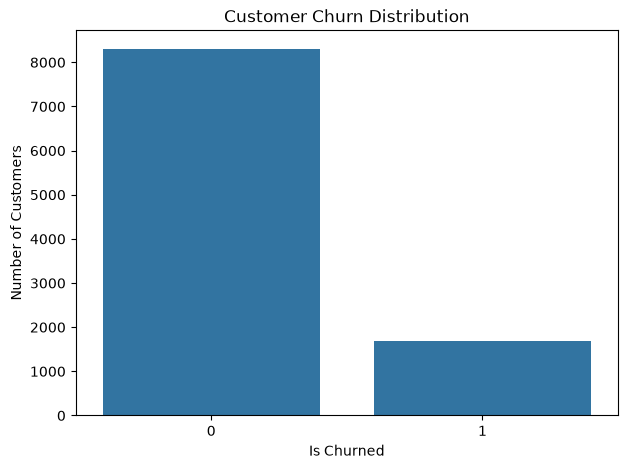

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=customers,
    x="is_churned"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Is Churned")
plt.ylabel("Number of Customers")

plt.show()

## 13. Numerical Data Summary

### Tujuan

Memahami distribusi awal variabel numerik.

### Customer variables

- age
- lifetime_value

### Product variables

- price
- avg_rating
- num_ratings
- stock_quantity
- discount_pct
- weight_kg

### Transaction variables

- quantity
- unit_price
- total_amount
- discount_applied
- shipping_cost

### Session variables

- duration_seconds
- pages_viewed
- converted
- bounced
- cart_additions

### Alasan

Distribusi numerik akan membantu mengidentifikasi:

- outliers,
- skewness,
- nilai tidak wajar,
- range,
- dan kandidat feature.

In [18]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"NUMERICAL SUMMARY: {name}")
    print(f"{'=' * 60}")

    display(df.describe().T)


NUMERICAL SUMMARY: customers


,count,mean,std,min,25%,50%,75%,max
age,10000.0,35.330600,11.168974,18.00,27.000,35.000,43.0000,75.00
is_churned,10000.0,0.169400,0.375124,0.00,0.000,0.000,0.0000,1.00
lifetime_value,10000.0,1544.610458,1426.692999,71.21,587.945,1043.805,1952.1475,9353.25
email_opt_in,10000.0,0.700500,0.458062,0.00,0.000,1.000,1.0000,1.00
has_app,10000.0,0.557200,0.496742,0.00,0.000,1.000,1.0000,1.00



NUMERICAL SUMMARY: products


,count,mean,std,min,25%,50%,75%,max
price,1000.0,57.60639,64.202408,3.71,19.77,36.085,68.925,520.45
avg_rating,1000.0,3.84940,0.779119,1.30,3.30,3.900,4.500,5.00
num_ratings,1000.0,248.66800,144.116895,0.00,121.00,247.000,370.250,499.00
stock_quantity,1000.0,503.77400,290.157796,1.00,250.00,510.000,752.250,999.00
discount_pct,1000.0,7.15000,13.786499,0.00,0.00,0.000,5.000,50.00
is_featured,1000.0,0.10300,0.304111,0.00,0.00,0.000,0.000,1.00
weight_kg,1000.0,1.52674,2.279980,0.05,0.49,0.950,1.750,50.00



NUMERICAL SUMMARY: transactions


,count,mean,std,min,25%,50%,75%,max
quantity,120000.0,1.469475,1.142298,1.00,1.00,1.00,1.00,19.00
unit_price,120000.0,53.502235,61.169967,2.68,18.52,33.23,64.44,520.45
total_amount,120000.0,78.448140,128.624378,2.68,21.46,40.58,85.12,6540.69
discount_applied,120000.0,7.110750,13.755153,0.00,0.00,0.00,5.00,50.00
shipping_cost,120000.0,4.058646,3.696181,0.00,0.00,4.83,7.41,9.99



NUMERICAL SUMMARY: sessions


,count,mean,std,min,25%,50%,75%,max
duration_seconds,80000.0,371.653875,433.931029,10.0,92.0,229.0,489.0,6408.0
pages_viewed,80000.0,6.487950,8.478244,1.0,1.0,3.0,8.0,142.0
converted,80000.0,0.108100,0.310509,0.0,0.0,0.0,0.0,1.0
bounced,80000.0,0.090675,0.287148,0.0,0.0,0.0,0.0,1.0
cart_additions,80000.0,0.858625,1.156095,0.0,0.0,0.0,2.0,5.0



NUMERICAL SUMMARY: reviews


,count,mean,std,min,25%,50%,75%,max
rating,25000.0,3.33316,1.090051,1.0,3.0,3.0,4.0,5.0
helpful_votes,25000.0,24.42604,14.462711,0.0,12.0,24.0,37.0,49.0
verified_purchase,25000.0,0.79928,0.400547,0.0,1.0,1.0,1.0,1.0


## 14. Initial Findings

### Tujuan

Mencatat temuan awal sebelum melakukan data cleaning,
feature engineering, dan machine learning.

### Hal yang perlu dicatat

Setelah menjalankan seluruh cell di atas, dokumentasikan:

1. Ukuran setiap dataset.
2. Missing values.
3. Duplicate records.
4. Primary key uniqueness.
5. Foreign key integrity.
6. Periode transaksi.
7. Distribusi transaction status.
8. Distribusi customer churn.
9. Distribusi variabel numerik.
10. Potensi data leakage.

### Important Finding

Dataset bersifat synthetic.

Oleh karena itu, hasil machine learning pada project ini akan digunakan
untuk menunjukkan kemampuan membangun end-to-end Data Science pipeline,
bukan sebagai klaim performa pada data perusahaan nyata.

### Next Step

Setelah eksplorasi selesai, tahap berikutnya adalah:

**Data Understanding → Business Problem Definition → Data Preparation**

Kita tidak langsung membuat model sebelum ketiga tahap tersebut selesai.

## 15. Business Questions

### Business Objective

Perusahaan e-commerce ingin memahami customer dan performa penjualan
untuk meningkatkan customer retention dan mendukung pengambilan
keputusan berbasis data.

### Primary Business Questions

#### 1. Customer Segmentation

Siapa customer yang memiliki nilai bisnis tinggi, sedang, dan rendah?

Metode yang akan dipertimbangkan:

- RFM Analysis
- K-Means Clustering

---

#### 2. Customer Churn

Customer mana yang memiliki kemungkinan churn lebih tinggi?

Target:

`customers.is_churned`

Output:

- churn probability
- churn classification
- important churn drivers

---

#### 3. Sales Performance

Bagaimana performa penjualan berdasarkan:

- waktu
- product category
- customer segment
- payment method
- country

Revenue definition akan menggunakan transaksi dengan status
`completed`, setelah divalidasi lebih lanjut.

---

#### 4. Sales Forecasting

Bagaimana pola penjualan dari waktu ke waktu dan bagaimana
perkiraan penjualan pada periode berikutnya?

Model forecasting akan dipilih setelah time-series analysis.

---

#### 5. Business Insight

Bagaimana hasil analysis dan machine learning dapat diterjemahkan
menjadi rekomendasi bisnis?

Contoh:

- customer retention
- customer prioritization
- sales planning
- campaign targeting
- inventory planning

### Important Principle

Machine learning model digunakan untuk menjawab business question,
bukan sebagai tujuan akhir project.

## 16. Potential Data Leakage

### Tujuan

Mengidentifikasi variabel yang berpotensi menyebabkan data leakage
sebelum membangun machine learning model.

### Churn Prediction

Target:

`is_churned`

Potential leakage:

- `segment`
- `lifetime_value`

### Segment

Dataset synthetic dapat memiliki hubungan langsung antara customer
segment dan churn status.

Oleh karena itu, `segment` tidak langsung digunakan sebagai feature
untuk churn prediction.

### Lifetime Value

`lifetime_value` perlu dianalisis lebih lanjut karena nilai tersebut
dapat merepresentasikan informasi yang dikumpulkan selama customer
lifetime.

Jika nilai tersebut mengandung informasi setelah periode prediksi,
maka penggunaannya dapat menyebabkan temporal leakage.

### Decision

Feature churn prediction akan ditentukan setelah dilakukan
temporal analysis dan feature engineering.

### General Rule

Semua feature untuk prediksi churn harus merepresentasikan informasi
yang tersedia sebelum prediction point.

## 17. Initial Project Scope

### Core Components

#### A. Customer Analytics

- Customer profiling
- RFM analysis
- Customer segmentation

#### B. Churn Prediction

- Feature engineering
- Classification model
- Churn probability
- Model evaluation
- Feature importance

#### C. Sales Analytics

- Revenue analysis
- Sales trend
- Product performance
- Customer contribution
- Category performance

#### D. Sales Forecasting

- Time-series analysis
- Forecast model
- Forecast evaluation

#### E. AI Business Insight

Structured analytical results will be provided to an AI layer.

The AI layer will:

- summarize findings,
- identify important patterns,
- explain business implications,
- generate actionable recommendations.

The AI layer will not calculate core business metrics independently.

### Deliverable

The final project will provide an end-to-end pipeline:

Data
→ Cleaning
→ Analysis
→ Feature Engineering
→ Machine Learning
→ Evaluation
→ Business Insight
→ Dashboard
→ Automation